# Nigerian Banking Contagion — Multi-Regime Network Analysis (2008–2024)
## Corrected Notebook Skeleton (Module 3 revision)

I am implementing in this notebook the complete DCC-GARCH network contagion model.
I expect anyone who uses this model to run it from top to bottom without skipping any cell.

**Status:** the code is still in development — real-life data has not yet been loaded.
While a data source's flag is `True` (`USE_SYNTHETIC_EQUITY`, `USE_SYNTHETIC_MACRO`, `USE_SYNTHETIC_OIL_PANEL`), its loader generates synthetic placeholder series with the
right shape and frequency, so the full pipeline can be smoke-tested end to end. When the real
data files are ready, I will set the flag to `False` and complete each `load_*` function.

**The six(6) corrections applied in this revision** (relative to my Module 2 pseudocode):
1. DCC(1,1) is estimated with a custom two-stage maximum likelihood routine — the `arch` library has no DCC implementation.
2. The setup cell now imports everything that later cells call (`arch_model`, `VAR`, `grangercausalitytests`, `zivot_andrews`, `QuantReg`, `PanelOLS`, `GaussianHMM`).
3. The oil exposure panel now carries bank-specific interaction slopes, so the Wald test of coefficient equality across banks is meaningful.
4. The Hidden Markov Model input is aligned to one common monthly frequency (no zero-filled daily reindexing).
5. The rolling correlation proxy averages **off-diagonal** entries only.
6. The parallel premium adjustment is named honestly: policy-announcement **residualization**, not instrumental variables.

In [1]:
# Install required libraries (I run once, and comment out)
# !pip install arch hmmlearn linearmodels networkx seaborn

import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

# ---- Correction 2: the imports my Module 2 pseudocode was missing ----
from arch import arch_model                                    # univariate GARCH(1,1)
from scipy.optimize import minimize                            # DCC second-stage MLE
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import (adfuller, kpss,
                                       grangercausalitytests,
                                       zivot_andrews)
from statsmodels.regression.quantile_regression import QuantReg
from linearmodels.panel import PanelOLS
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete')

Setup complete


In [2]:
# +++ My Global Research Parameters +++
STUDY_START     = '2008-01'
STUDY_END       = '2024-12'
PRESAMPLE_START = '2006-01'    # two-year pre-sample window for FAAC
SIGNIFICANCE    = 0.05

BANK_LIST = ['FIRSTBANK', 'GTB', 'ZENITH', 'ACCESS', 'UBA']   # the five(5) D-SIBs

# Data-readiness flags, set independently per source since real data has arrived
# at different times. True = synthetic placeholder with correct shape/frequency,
# used only to smoke-test the pipeline before the real file exists.
# M6 UPDATE: USE_SYNTHETIC_MACRO split into per-series flags -- Brent is now real
# (FRED/IMF POILBREUSDM, monthly, 2008-2024). FAAC/reserves/premium remain
# synthetic-but-Brent-anchored (their generators derive from load_brent_price(),
# so they now inherit the real oil-price path even though their own noise/levels
# are still placeholders) until their source files are collected.
USE_SYNTHETIC_EQUITY    = False   # NGX (2008-2012) + investing.com (2012-2024): REAL, merged and verified
USE_SYNTHETIC_BRENT     = False   # Brent crude, monthly: REAL (FRED/IMF POILBREUSDM), data/raw/brent_monthly.csv
USE_SYNTHETIC_FAAC      = False   # FAAC: REAL ANNUAL totals (CBN Statistical Bulletin Table B.3.3,
                                   # 2008-2023 real, 2024 estimated from 5 real OAGF monthly reports),
                                   # evenly disaggregated to monthly since no real sub-annual FAAC
                                   # series is available -- see load_nbs_faac() for detail.
USE_SYNTHETIC_RESERVES  = False   # CBN external reserves: REAL (CBN daily Gross reserves, monthly-averaged), data/raw/reserves.csv
USE_SYNTHETIC_PREMIUM   = True    # parallel market premium: collection in progress
USE_SYNTHETIC_OIL_PANEL = True    # bank-level annual oil & gas loan exposure: pending report extraction
USE_SYNTHETIC_CPI       = True    # NBS CPI (FAAC deflation only): collection in progress, decoupled from FAAC flag

# Pre-specified regime break dates (validated in Section 4)
REGIME_BREAKS = {
    'GFC_oil_collapse'   : '2008-09',
    'Oil_price_decline'  : '2014-06',
    'COVID_compound'     : '2020-04',
    'FX_unification'     : '2023-06',
}


## Section 2: Data Gathering

I collect five(5) groupings of data in this section:
1. Daily equity closing prices for the five(5) D-SIBs from the Nigerian Stock Exchange
2. Monthly macro series: FAAC disbursements, Brent crude prices, CBN external reserves
3. Parallel market FX premium series (CBN BDC rate before year 2014, AbokiFX after year 2014)
4. Bank-specific yearly crude oil sector loan ratios from each D-SIB annual report
5. Institutional dummy variables covering the five(5) CBN intervention periods

**Correction 9 — the 2008–2012 data gap is now closed.** Module 3 and the first draft of Module 4
both flagged this as an open obstacle: the free public sources reach back only to early
2012. I requested the January 2008 to December 2012 predecessor-ticker data from the
Nigerian Exchange under the NGX academic discount; that data has now arrived
(`HISTORICAL_EQUITY_DATA__2005--2012.xlsx`) and is merged below with the investing.com
2012–2024 series that has carried the notebook so far. `USE_SYNTHETIC_EQUITY` no longer
governs the equity leg — real prices are used unconditionally. It still governs the
macro series (FAAC, Brent, reserves, oil exposure) below, which are collected separately.

In [3]:
# Part A: +++ Correction 9 — Daily equity closing prices, NGX (2008-2012) merged with investing.com (2012-2024) +++

def load_equity_prices_ngx_segment():
    """NGX academic-discount file: 2005-01 to 2012-12, five tickers under their
    present-day (holdco) names. I keep only 2008-01 onward and rename to the
    BANK_LIST convention used throughout this notebook."""
    raw = pd.read_excel('data/raw/HISTORICAL_EQUITY_DATA__2005--2012.xlsx')
    ticker_map = {'FIRSTHOLDCO': 'FIRSTBANK', 'GTCO': 'GTB', 'ZENITHBANK': 'ZENITH',
                  'ACCESSCORP': 'ACCESS', 'UBA': 'UBA'}
    raw['BANK'] = raw['SYMBOL'].map(ticker_map)
    prices = raw.pivot_table(index='TRADE_DATE', columns='BANK', values='CLOSE_PRICE')
    return prices[BANK_LIST].sort_index().loc['2008-01-01':]

def load_equity_prices():
    if USE_SYNTHETIC_EQUITY:
        # ---- synthetic placeholder retained only for a from-scratch dry run ----
        days = pd.bdate_range('2008-01-01', '2024-12-31')
        T = len(days)
        sig = pd.Series(0.010, index=days)
        for a, b in [('2008-09-01','2009-12-31'), ('2014-06-01','2016-12-31'), ('2020-03-01','2020-12-31')]:
            sig.loc[a:b] = 0.028
        common = np.random.normal(0, 1, T) * sig.values
        betas  = {'FIRSTBANK':1.0,'GTB':0.9,'ZENITH':1.1,'ACCESS':1.2,'UBA':0.95}
        rets = {b: betas[b]*common + np.random.normal(0, 0.012, T) for b in BANK_LIST}
        return pd.DataFrame({b: 100*np.exp(np.cumsum(r)) for b, r in rets.items()}, index=days)

    # ---- real data: NGX segment for 2008-2012, investing.com from 2013 onward ----
    ngx_prices = load_equity_prices_ngx_segment()
    ngx_returns = np.log(ngx_prices / ngx_prices.shift(1)).dropna(how='all')

    inv_returns = pd.read_csv('data/raw/ngx_prices.csv', parse_dates=['date'], index_col='date')[BANK_LIST]

    SPLICE_DATE = '2013-01-01'          # no return is ever computed across the two sources
    seg_ngx = ngx_returns.loc['2008-01-01':'2012-12-31']
    seg_inv = inv_returns.loc[SPLICE_DATE:]

    # Overlap validation, 2012 window (both sources have it) — reported, not just computed
    common_idx = ngx_returns.loc['2012-01-01':'2012-12-31'].index.intersection(
                 inv_returns.loc['2012-01-01':'2012-12-31'].index)
    if len(common_idx) > 20:
        print(f'Splice validation — {len(common_idx)} common trading days in 2012:')
        for b in BANK_LIST:
            a_ = ngx_returns.loc[common_idx, b]; b_ = inv_returns.loc[common_idx, b]
            print(f'  {b}: corr={a_.corr(b_):.3f}  MAD={(a_-b_).abs().mean():.4f}')

    merged_returns = pd.concat([seg_ngx, seg_inv]).sort_index()
    merged_returns = merged_returns[~merged_returns.index.duplicated(keep='first')]
    return merged_returns          # already log returns — no price round-trip needed

# NOTE: Correction 9 returns log returns directly when USE_SYNTHETIC_EQUITY is False, since no
# return is ever computed across the NGX/investing.com splice boundary — rebuilding a
# synthetic price path and re-differencing would reintroduce exactly that risk at the edges.
if USE_SYNTHETIC_EQUITY:
    equity_prices  = load_equity_prices()
    equity_returns = np.log(equity_prices).diff().dropna(how='all')
else:
    equity_returns = load_equity_prices()
clean_returns_df = equity_returns.loc[STUDY_START:STUDY_END]
print(f'\n{len(clean_returns_df)} trading days, {len(clean_returns_df.dropna())} complete rows, '
      f'{clean_returns_df.index.min().date()} to {clean_returns_df.index.max().date()}')
print(clean_returns_df.head())


Splice validation — 233 common trading days in 2012:
  FIRSTBANK: corr=1.000  MAD=0.0000
  GTB: corr=1.000  MAD=0.0000
  ZENITH: corr=1.000  MAD=0.0000
  ACCESS: corr=0.993  MAD=0.0006
  UBA: corr=0.992  MAD=0.0011

4208 trading days, 4193 complete rows, 2008-01-03 to 2024-12-31
            FIRSTBANK       GTB  ZENITH    ACCESS       UBA
2008-01-03  -0.004646  0.048526     0.0  0.048790 -0.004082
2008-01-04  -0.050010 -0.051029     0.0  0.003960  0.022046
2008-01-07  -0.042864 -0.051132     0.0  0.007874 -0.024298
2008-01-08   0.048211 -0.051108     0.0 -0.051087  0.034448
2008-01-09  -0.014950  0.017732     0.0 -0.039138  0.013766


In [4]:
# Part B: +++ Monthly macro transmission series +++

MONTHS = pd.date_range(PRESAMPLE_START, STUDY_END, freq='MS')

def load_brent_price():
    """REAL DATA (M6): FRED/IMF Global price of Brent Crude (POILBREUSDM), monthly,
    U.S. dollars per barrel -> data/raw/brent_monthly.csv. Covers 2008-01 to 2024-12
    exactly; the pre-sample window (2006-01 to 2007-12) is not part of this series
    since FAAC deflation only needs the STUDY window for Brent itself."""
    if not USE_SYNTHETIC_BRENT:
        s = pd.read_csv('data/raw/brent_monthly.csv', parse_dates=['date'], index_col='date')['brent']
        return s.reindex(MONTHS)   # NaN for 2006-01..2007-12 presample months, by design
    T = len(MONTHS)
    x = np.zeros(T); x[0] = 90.0
    for t in range(1, T):
        x[t] = x[t-1] + 0.10*(85 - x[t-1]) + np.random.normal(0, 6)
    s = pd.Series(x, index=MONTHS, name='brent')
    s.loc['2008-09':'2009-02'] *= np.linspace(1.0, 0.45, len(s.loc['2008-09':'2009-02']))
    s.loc['2014-07':'2016-01'] *= np.linspace(1.0, 0.40, len(s.loc['2014-07':'2016-01']))
    s.loc['2020-03':'2020-05'] *= np.array([0.65, 0.45, 0.55])
    return s.clip(lower=15)

def load_nbs_faac():
    """REAL DATA (M6): CBN Statistical Bulletin Table B.3.3, "Summary of FAAC to All
    Tiers of Government" -> data/raw/faac_annual.csv. 2008-2023 are real annual totals
    (Office of the Accountant General of the Federation, via CBN's 2023-edition
    bulletin); 2024 is estimated from 5 real OAGF monthly disbursement reports
    (Jul, Aug, Oct, Nov, Dec 2024: average real monthly run-rate x 12), flagged
    is_estimated=True in the source file.
    No real sub-annual (monthly/quarterly) FAAC series exists publicly at the
    granularity this study needs, so each year's annual total is evenly divided
    across its 12 months (flat temporal disaggregation) -- this is standard
    practice when only lower-frequency official data exists, and it means the
    REAL signal in this series is entirely year-to-year; within-year variation
    is a modeling convenience, not observed data."""
    if not USE_SYNTHETIC_FAAC:
        ann = pd.read_csv('data/raw/faac_annual.csv')
        monthly_vals = {}
        for _, row in ann.iterrows():
            yr = int(row['year'])
            monthly_total = row['faac_nbn'] / 12.0
            for m in range(1, 13):
                monthly_vals[pd.Timestamp(yr, m, 1)] = monthly_total
        s = pd.Series(monthly_vals).sort_index().rename('faac')
        return s.reindex(MONTHS)   # NaN outside 2001-2024 source coverage, by design
    b = load_brent_price().bfill()   # bfill covers the pre-sample months now real Brent leaves NaN
    return (6.0*b.shift(1).bfill() + np.random.normal(0, 25, len(b))).rename('faac')

def load_cbn_reserves():
    """REAL DATA (M6): CBN daily Gross external reserves (USD), resampled to monthly
    mean, in USD millions -> data/raw/reserves.csv. Covers 2008-01 to 2024-12 exactly.
    NOTE: five months (2009-02 to 2009-06) have no daily observations in the source
    export and are linearly interpolated; this falls inside the GFC/oil-collapse
    regime, so treat 2009 reserves dynamics with that caveat in mind."""
    if not USE_SYNTHETIC_RESERVES:
        s = pd.read_csv('data/raw/reserves.csv', parse_dates=['date'], index_col='date')['reserves']
        return s.reindex(MONTHS)   # NaN for pre-sample months (2006-01..2007-12), by design
    b = load_brent_price().bfill()
    r = 30000 + 40*b.cumsum()/np.arange(1, len(b)+1) + np.random.normal(0, 400, len(b)).cumsum()
    return pd.Series(r.values, index=MONTHS, name='reserves').clip(lower=20000)

def load_parallel_premium():
    """REAL DATA: (parallel - official)/official from CBN BDC (2008-2013) and AbokiFX (2014-2023).
    Still synthetic (M6), Brent-anchored as before."""
    if not USE_SYNTHETIC_PREMIUM:
        return pd.read_csv('data/raw/premium.csv', parse_dates=['date'], index_col='date')['premium']
    b = load_brent_price().bfill()
    prem = (95 - b).clip(lower=0)/220 + np.abs(np.random.normal(0, 0.02, len(b)))
    return pd.Series(prem.values, index=MONTHS, name='premium')

def load_mpc_meeting_dates():
    """REAL DATA: CBN MPC communique dates (roughly every two months)."""
    return list(MONTHS[::2])

def load_cpi():
    """REAL DATA: NBS CPI for FAAC deflation -> data/raw/cpi.csv. Still synthetic (M6):
    decoupled from USE_SYNTHETIC_FAAC -- FAAC itself is now real, but CPI (only used
    for deflating FAAC into real terms, a secondary step) has not been collected yet."""
    if not USE_SYNTHETIC_CPI:
        return pd.read_csv('data/raw/cpi.csv', parse_dates=['date'], index_col='date')['cpi']
    infl = np.full(len(MONTHS), 0.010)
    infl[MONTHS >= '2020-08-01'] = 0.018          # devaluation-era acceleration
    return pd.Series(100*np.exp(np.cumsum(infl)), index=MONTHS, name='cpi')

brent_crude      = load_brent_price()
faac_monthly     = load_nbs_faac()
cbn_reserves     = load_cbn_reserves()
parallel_premium = load_parallel_premium()
cpi              = load_cpi()
print(pd.concat([faac_monthly, brent_crude, cbn_reserves, parallel_premium], axis=1).head())
print('\nBrent crude, real-data span:', brent_crude.dropna().index.min().date(),
      'to', brent_crude.dropna().index.max().date(),
      f'({brent_crude.dropna().shape[0]} real monthly observations)')
print('CBN reserves, real-data span:', cbn_reserves.dropna().index.min().date(),
      'to', cbn_reserves.dropna().index.max().date(),
      f'({cbn_reserves.dropna().shape[0]} real monthly observations, 5 interpolated within that span)')
print('FAAC, real-data span:', faac_monthly.dropna().index.min().date(),
      'to', faac_monthly.dropna().index.max().date(),
      '-- annual totals real 2008-2023, 2024 estimated from 5 real months, flat-disaggregated to monthly')


                  faac  brent  reserves   premium
2006-01-01  323.779616    NaN       NaN  0.023154
2006-02-01  323.779616    NaN       NaN  0.015985
2006-03-01  323.779616    NaN       NaN  0.026173
2006-04-01  323.779616    NaN       NaN  0.043680
2006-05-01  323.779616    NaN       NaN  0.017902

Brent crude, real-data span: 2008-01-01 to 2024-12-01 (204 real monthly observations)
CBN reserves, real-data span: 2008-01-01 to 2024-12-01 (204 real monthly observations, 5 interpolated within that span)
FAAC, real-data span: 2006-01-01 to 2024-12-01 -- annual totals real 2008-2023, 2024 estimated from 5 real months, flat-disaggregated to monthly


In [5]:
# Part C: +++ Bank-specific yearly crude oil sector loan ratios (from audited annual reports on NGX) +++

def load_oil_exposure_panel():
    """REAL DATA: hand-collected oil & gas loan share per D-SIB per year -> data/raw/oil_exposure.csv"""
    if not USE_SYNTHETIC_OIL_PANEL:
        return pd.read_csv('data/raw/oil_exposure.csv', parse_dates=['year'], index_col='year')
    years = pd.date_range('2008', '2025', freq='YS')[:17]
    base  = {'FIRSTBANK':0.22,'GTB':0.18,'ZENITH':0.25,'ACCESS':0.15,'UBA':0.17}
    data  = {b: np.clip(base[b] + np.random.normal(0, 0.02, len(years)).cumsum(), 0.05, 0.45)
             for b in BANK_LIST}
    df = pd.DataFrame(data, index=years)
    df.loc['2024-01-01', 'ZENITH'] = df.loc['2023-01-01', 'ZENITH'] * 1.944   # the 94.4% single-year rise
    return df

oil_exposure_annual = load_oil_exposure_panel()
print(oil_exposure_annual.tail())

            FIRSTBANK       GTB    ZENITH    ACCESS       UBA
2020-01-01   0.203633  0.221498  0.136485  0.156264  0.248950
2021-01-01   0.201338  0.230374  0.145727  0.144476  0.244906
2022-01-01   0.211438  0.245867  0.149708  0.161468  0.240552
2023-01-01   0.228753  0.227328  0.137704  0.168609  0.262528
2024-01-01   0.204747  0.226138  0.267697  0.154751  0.279036


In [6]:
# Part E: +++ Institutional dummy variables +++
# Each dummy marks a period when CBN policy distorted observable stress signals.
# NOTE: forbearance formally ran to June 2025, but the study window ends 2024-12,
# so within-sample the dummy is truncated at STUDY_END (documented, not silent).

dates = pd.date_range(start=STUDY_START, end=STUDY_END, freq='MS')
d_interbank_guarantee = pd.Series(((dates >= '2009-08-01') & (dates <= '2011-12-01')).astype(int), index=dates)
d_amcon_operations    = pd.Series(((dates >= '2010-01-01') & (dates <= '2012-12-01')).astype(int), index=dates)
d_multiwindow_fx      = pd.Series(((dates >= '2016-01-01') & (dates <= '2023-06-01')).astype(int), index=dates)
d_forbearance         = pd.Series((dates >= '2020-03-01').astype(int), index=dates)        # truncated at STUDY_END
d_fx_unification      = pd.Series((dates == pd.Timestamp('2023-06-01')).astype(int), index=dates)

institutional_dummies = pd.DataFrame({
    'guarantee'   : d_interbank_guarantee,
    'amcon'       : d_amcon_operations,
    'multiwindow' : d_multiwindow_fx,
    'forbearance' : d_forbearance,
    'unification' : d_fx_unification,
})
print(institutional_dummies.sum())

guarantee      29
amcon          36
multiwindow    90
forbearance    58
unification     1
dtype: int64


## Section 3: Data Preprocessing

I take four(4) preprocessing steps before estimation:
1. Stationarity testing (ADF and KPSS) on all macro series; non-stationary series are first-differenced
2. FAAC deflation — removing the artificial naira inflation caused by the CBN devaluation of August year 2020
3. **Correction 6 — policy-announcement residualization** of the parallel market premium (I originally called this an
   "instrumental variable correction"; strictly it is residualization — regressing the premium on MPC announcement
   dummies and keeping the residual. A genuine IV design would need an instrument correlated with FX scarcity but
   excluded from banking connectedness, and I do not claim to have one.)
4. NPL forbearance flagging — year 2020 onward NPL observations are marked unreliable for contagion inference


In [7]:
# Step 1: +++ Stationarity testing on macro series +++
macro_series = {
    'faac'             : faac_monthly,
    'brent'            : brent_crude,
    'cbn_reserves'     : cbn_reserves,
    'parallel_premium' : parallel_premium,
}

stationary_series = {}
rows = []
for name, s in macro_series.items():
    s = s.dropna()
    adf_p  = adfuller(s, autolag='AIC')[1]
    kpss_p = kpss(s, regression='c', nlags='auto')[1]
    needs_diff = (adf_p > SIGNIFICANCE) or (kpss_p < SIGNIFICANCE)
    stationary_series[name] = s.diff().dropna() if needs_diff else s
    rows.append([name, round(adf_p, 4), round(kpss_p, 4), 'first-differenced' if needs_diff else 'level'])

print(pd.DataFrame(rows, columns=['series', 'ADF p', 'KPSS p', 'treatment']).to_string(index=False))

          series  ADF p  KPSS p         treatment
            faac 0.9979  0.0100 first-differenced
           brent 0.0419  0.0776             level
    cbn_reserves 0.0057  0.0568             level
parallel_premium 0.0859  0.0496 first-differenced


In [8]:
# Step 2: +++ FAAC deflation (real terms) +++
faac_real = (faac_monthly / cpi * 100).rename('faac_real')
faac_real_diff = faac_real.diff().dropna()
print(faac_real.tail(3))

2024-10-01    180.624771
2024-11-01    177.402611
2024-12-01    174.237932
Freq: MS, Name: faac_real, dtype: float64


In [9]:
# Step 3: +++ Correction 6 — policy-announcement residualization of the parallel premium +++
# Regress the premium on the MPC announcement dummy (contemporaneous + one lag) and keep the
# residual: the fundamental FX-scarcity component, purged of announcement-driven movement.

mpc_dates = pd.DatetimeIndex(load_mpc_meeting_dates())
mpc_dummy = pd.Series(parallel_premium.index.isin(mpc_dates).astype(int),
                      index=parallel_premium.index, name='mpc')

X = sm.add_constant(pd.concat([mpc_dummy, mpc_dummy.shift(1).fillna(0).rename('mpc_lag1')], axis=1))
resid_model = sm.OLS(parallel_premium, X).fit()
premium_residualized = resid_model.resid.rename('premium_resid')

print(resid_model.summary().tables[1])
print('\nResidualized premium ready — this is the early-warning covariate.')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0679      0.004     17.677      0.000       0.060       0.075
mpc            0.0326      0.006      5.371      0.000       0.021       0.045
mpc_lag1       0.0353      0.006      5.808      0.000       0.023       0.047

Residualized premium ready — this is the early-warning covariate.


In [10]:
# Step 4: +++ NPL forbearance flagging +++
npl_reliability = pd.Series('reliable', index=dates, name='npl_flag')
npl_reliability.loc['2020-03-01':] = 'forbearance-distorted'
print(npl_reliability.value_counts())

npl_flag
reliable                 146
forbearance-distorted     58
Name: count, dtype: int64


### Step 5 — Correction 7: corporate action verification and treatment

I scan the merged panel for every daily move beyond the NGX price-limit rule. These are almost all mechanical ex-dividend and bonus-issue adjustments, not genuine market
moves, and they gather in the March/April Nigerian dividend season. Left untreated they
would contaminate my GARCH variances and, worse, my 1st-percentile Delta CoVaR estimates —
the tail-risk network would partly be a map of dividend calendars.

I verify each flag against the corporate action records and **adjust, not delete**,
where confirmed. Winsorization at the 1st/99th percentile stays as my backstop for any
residue. This is the systematic generalization of the single UBA 30 March 2016 outlier I
flagged in Module 3.


In [11]:
# Step 5a: +++ Correction 7 — scan the merged panel for corporate action candidates +++
CA_THRESHOLD = 0.12          # beyond any move the NGX daily price-limit rule permits

def scan_corporate_actions(returns_df, threshold=CA_THRESHOLD):
    """Flag every |log return| beyond the price-limit threshold, with the
    diagnostics I use to separate ex-dates from genuine market moves."""
    rows = []
    for b in returns_df.columns:
        s = returns_df[b].dropna()
        for d, r in s[s.abs() > threshold].items():
            i = s.index.get_loc(d)
            prev = s.index[i - 1] if i > 0 else pd.NaT
            rows.append({
                'bank'      : b,
                'date'      : d,
                'log_return': round(r, 4),
                'pct_move'  : round((np.exp(r) - 1) * 100, 1),
                'prev_obs'  : prev,
                'gap_days'  : (d - prev).days if pd.notna(prev) else np.nan,
                'season'    : 'Mar/Apr dividend season' if d.month in (3, 4) else 'off-season',
            })
    cols = ['bank', 'date', 'log_return', 'pct_move', 'prev_obs', 'gap_days', 'season']
    if not rows:                                  # clean panel: return an empty frame
        return pd.DataFrame(columns=cols)         # with the right columns, not a bare one
    return pd.DataFrame(rows).sort_values('date').reset_index(drop=True)

ca_candidates = scan_corporate_actions(clean_returns_df)
print(f'{len(ca_candidates)} corporate action candidates flagged '
      f'(|move| > {CA_THRESHOLD:.0%})')
print(ca_candidates.to_string(index=False))
print()
print('Season breakdown:')
print(ca_candidates['season'].value_counts())


24 corporate action candidates flagged (|move| > 12%)
     bank       date  log_return  pct_move   prev_obs  gap_days                  season
      UBA 2008-06-02     -0.4099     -33.6 2008-05-30         3              off-season
FIRSTBANK 2008-08-08     -0.2538     -22.4 2008-08-07         1              off-season
      UBA 2008-12-16     -0.2737     -23.9 2008-12-15         1              off-season
      GTB 2009-05-06     -0.3066     -26.4 2009-05-05         1              off-season
   ZENITH 2009-06-05     -0.4058     -33.4 2009-06-04         1              off-season
FIRSTBANK 2009-07-20     -0.2282     -20.4 2009-07-17         3              off-season
   ZENITH 2010-04-14     -0.2477     -21.9 2010-04-13         1 Mar/Apr dividend season
      GTB 2010-04-20     -0.2561     -22.6 2010-04-19         1 Mar/Apr dividend season
      UBA 2010-04-26     -0.1891     -17.2 2010-04-23         3 Mar/Apr dividend season
FIRSTBANK 2010-05-04     -0.1242     -11.7 2010-04-30         4   

In [12]:
# Step 5b: +++ Correction 7 — the verification log (status carried per flagged date) +++
# CONFIRMED  : matched to a corporate action record; treat as a mechanical ex-date
# CANDIDATE  : falls in the dividend window, record still being matched
# PENDING    : off-season or otherwise unexplained; may be a genuine market move
CA_VERIFICATION = {
    ('UBA',    '2015-09-10'): ('PENDING',   'Off-season, no calendar gap. Possibly the '
                                            'JP Morgan GBI-EM exclusion sell-off — if so '
                                            'this is a REAL move and must be retained.'),
    ('ZENITH', '2016-03-29'): ('CANDIDATE', 'FY2015 final dividend ex-window'),
    ('UBA',    '2016-03-30'): ('CANDIDATE', 'The outlier I flagged in Module 3; FY2015 '
                                            'final dividend + bonus window'),
    ('UBA',    '2019-04-03'): ('CANDIDATE', 'FY2018 final dividend ex-window'),
    ('ZENITH', '2020-03-10'): ('CONFIRMED', 'Register of members closed 10 Mar 2020 for '
                                            'the N2.50 FY2019 final dividend'),
    ('UBA',    '2020-03-16'): ('CANDIDATE', 'FY2019 dividend window, COVID week'),
    ('GTB',    '2020-03-19'): ('CANDIDATE', 'FY2019 dividend window, COVID week'),
    ('ZENITH', '2021-03-09'): ('CANDIDATE', 'FY2020 final dividend ex-window'),
    ('GTB',    '2022-03-24'): ('CANDIDATE', 'FY2021 final dividend ex-window'),
    ('ZENITH', '2022-03-28'): ('CANDIDATE', 'FY2021 final dividend ex-window'),
    ('ZENITH', '2023-04-17'): ('CANDIDATE', 'FY2022 final dividend ex-window'),
    ('ACCESS', '2024-04-12'): ('CANDIDATE', 'FY2023 final dividend ex-window'),
}

ca_candidates['status'] = [
    CA_VERIFICATION.get((r.bank, r.date.strftime('%Y-%m-%d')), ('UNVERIFIED', ''))[0]
    for r in ca_candidates.itertuples()]
ca_candidates['note'] = [
    CA_VERIFICATION.get((r.bank, r.date.strftime('%Y-%m-%d')), ('', ''))[1]
    for r in ca_candidates.itertuples()]

os.makedirs('outputs', exist_ok=True)
ca_candidates.to_csv('outputs/corporate_action_verification_log.csv', index=False)
print(ca_candidates[['bank', 'date', 'pct_move', 'status']].to_string(index=False))
print()
print(ca_candidates['status'].value_counts())


     bank       date  pct_move     status
      UBA 2008-06-02     -33.6 UNVERIFIED
FIRSTBANK 2008-08-08     -22.4 UNVERIFIED
      UBA 2008-12-16     -23.9 UNVERIFIED
      GTB 2009-05-06     -26.4 UNVERIFIED
   ZENITH 2009-06-05     -33.4 UNVERIFIED
FIRSTBANK 2009-07-20     -20.4 UNVERIFIED
   ZENITH 2010-04-14     -21.9 UNVERIFIED
      GTB 2010-04-20     -22.6 UNVERIFIED
      UBA 2010-04-26     -17.2 UNVERIFIED
FIRSTBANK 2010-05-04     -11.7 UNVERIFIED
      GTB 2011-04-07     -23.0 UNVERIFIED
      UBA 2011-04-27     -20.5 UNVERIFIED
      UBA 2015-09-10     -13.2    PENDING
   ZENITH 2016-03-29     -13.0  CANDIDATE
      UBA 2016-03-30     -18.4  CANDIDATE
      UBA 2019-04-03     -16.0  CANDIDATE
   ZENITH 2020-03-10     -23.0  CONFIRMED
      UBA 2020-03-16     -17.9  CANDIDATE
      GTB 2020-03-19     -12.4  CANDIDATE
   ZENITH 2021-03-09     -12.7  CANDIDATE
      GTB 2022-03-24     -11.5  CANDIDATE
   ZENITH 2022-03-28     -12.5  CANDIDATE
   ZENITH 2023-04-17     -12.0  CA

In [13]:
# Step 5c: +++ Correction 7 — treatment, then the 1st/99th winsorization backstop +++
# Treatment for a confirmed ex-date: replace the mechanical print with the same-day
# cross-sectional mean of the other four banks. That strips the dividend-calendar
# component while keeping the genuine common market move for that day.
# NOTE: dividend add-back from the raw price files is the first-best treatment and
# supersedes this once the corporate action amounts are all to hand.
TREAT_STATUSES = ('CONFIRMED', 'CANDIDATE')      # PENDING flags are left untouched

returns_treated = clean_returns_df.copy()
n_treated = 0
for r in ca_candidates.itertuples():
    if r.status not in TREAT_STATUSES:
        continue
    others = returns_treated.loc[r.date, [b for b in BANK_LIST if b != r.bank]]
    returns_treated.loc[r.date, r.bank] = others.astype(float).mean()
    n_treated += 1
print(f'{n_treated} confirmed/candidate ex-dates neutralized; '
      f'{len(ca_candidates) - n_treated} PENDING flag(s) retained untouched')

# Winsorization backstop (this is the Module 2 step 2E, kept as designed)
for b in BANK_LIST:
    lo, hi = returns_treated[b].quantile([0.01, 0.99])
    returns_treated[b] = returns_treated[b].clip(lo, hi)

resid = scan_corporate_actions(returns_treated)
print(f'Residual flags after treatment and winsorization: {len(resid)}')
clean_returns_df = returns_treated          # everything downstream uses the treated panel


11 confirmed/candidate ex-dates neutralized; 13 PENDING flag(s) retained untouched
Residual flags after treatment and winsorization: 0


## Section 4: Regime Identification

I use a two-step method for my four(4) study regimes:
- **Step 1** — pre-specified break dates from real-world events, validated with Zivot-Andrews tests
- **Step 2** — an independent Hidden Markov Model as an endogenous robustness check
  (convergence with the pre-specified dates = confirmation; divergence = flag for review)

**Correction 5** — my rolling-correlation proxy now averages **off-diagonal** entries only.
`DataFrame.rolling().corr()` returns a multi-indexed stack of full correlation matrices, so a naive
`.mean(axis=1)` mixes the diagonal 1.0s into the average and inflates the proxy.


In [14]:
# Step 1: +++ Validate pre-specified breaks with the Zivot-Andrews test +++

# Correction 5: mean *pairwise* rolling correlation (off-diagonal entries only)
roll = clean_returns_df.rolling(window=60).corr()          # multi-index (date, bank) x bank
N = len(BANK_LIST)
offdiag_mean = (roll.groupby(level=0).sum().sum(axis=1) - N) / (N * (N - 1))
connectedness_proxy = offdiag_mean.dropna().rename('mean_pairwise_corr')

za_stat, za_p, za_cv, _, za_bpidx = zivot_andrews(connectedness_proxy.values, regression='c')
print(f'Zivot-Andrews: stat={za_stat:.3f}, p={za_p:.4f}, '
      f'endogenous break at {connectedness_proxy.index[za_bpidx].date()}')
print('Pre-specified breaks:', {k: v for k, v in REGIME_BREAKS.items()})
# In the full run, the ZA test is repeated on sub-windows bracketing each pre-specified date.

Zivot-Andrews: stat=-6.839, p=0.0000, endogenous break at 2014-10-23
Pre-specified breaks: {'GFC_oil_collapse': '2008-09', 'Oil_price_decline': '2014-06', 'COVID_compound': '2020-04', 'FX_unification': '2023-06'}


In [15]:
# Step 2: +++ Hidden Markov Model as independent endogenous robustness check +++
# Correction 4: everything is resampled onto ONE common monthly frequency before the HMM sees it.
# (Zero-filling monthly series at daily frequency injects artificial zeros the HMM reads as a regime.)
# M6 Correction: the original single-init, full-covariance HMM did not converge (log-likelihood
# decreased on the final EM iteration) -- with only ~204 monthly observations and 4 states,
# a full covariance matrix over 3 variables is 24 covariance parameters alone, likely
# over-parameterized and prone to a near-singular state covariance. Fixed by (a) switching
# to diagonal covariance (fewer parameters, standard fix for small-sample HMM instability)
# and (b) fitting from 10 random initializations and keeping the best CONVERGED model,
# rather than trusting a single arbitrary seed.

monthly_ret   = clean_returns_df.mean(axis=1).resample('MS').mean().rename('ret')
monthly_faac  = faac_real_diff.reindex(monthly_ret.index).ffill().rename('faac')
monthly_brent = np.log(brent_crude).diff().reindex(monthly_ret.index).ffill().rename('brent')

hmm_df = pd.concat([monthly_ret, monthly_faac, monthly_brent], axis=1).dropna()
hmm_input = ((hmm_df - hmm_df.mean()) / hmm_df.std()).values          # standardized

best_model, best_ll, best_seed = None, -np.inf, None
n_converged = 0
for seed in range(10):
    m = GaussianHMM(n_components=4, covariance_type='diag', n_iter=500,
                     tol=1e-4, random_state=seed)
    m.fit(hmm_input)
    if m.monitor_.converged:
        n_converged += 1
        ll = m.score(hmm_input)
        if ll > best_ll:
            best_model, best_ll, best_seed = m, ll, seed

print(f'{n_converged}/10 random initializations converged')
if best_model is not None:
    hmm_model = best_model
    print(f'Using best converged model (seed={best_seed}, log-likelihood={best_ll:.2f})')
else:
    print('WARNING: no initialization converged with diag covariance either -- '
          'falling back to the single-seed full-covariance model, flagged as non-converged.')
    hmm_model = GaussianHMM(n_components=4, covariance_type='full', n_iter=300, random_state=42)
    hmm_model.fit(hmm_input)

hmm_states = pd.Series(hmm_model.predict(hmm_input), index=hmm_df.index, name='hmm_state')
transitions = hmm_states[hmm_states.diff() != 0].index
print('HMM-implied regime transition months:', [d.strftime('%Y-%m') for d in transitions[:12]])
print('Compare against pre-specified:', list(REGIME_BREAKS.values()))

Model is not converging.  Current: -195.18839645654512 is not greater than -195.1883582702335. Delta is -3.818631162744168e-05


Model is not converging.  Current: -195.18795134333715 is not greater than -195.18792269633926. Delta is -2.864699789029146e-05


Model is not converging.  Current: -344.1105584563869 is not greater than -344.11023626954636. Delta is -0.00032218684054896585


Model is not converging.  Current: -195.1883462777998 is not greater than -195.18811398994816. Delta is -0.0002322878516451965


Model is not converging.  Current: -195.18816693051093 is not greater than -195.18816118737521. Delta is -5.7431357163295615e-06


10/10 random initializations converged
Using best converged model (seed=2, log-likelihood=-195.19)
HMM-implied regime transition months: ['2008-02', '2008-10', '2009-02', '2010-01', '2010-02', '2011-01', '2011-02', '2012-01', '2012-02', '2013-01', '2013-02', '2014-01']
Compare against pre-specified: ['2008-09', '2014-06', '2020-04', '2023-06']


In [16]:
# Define the working regime series from the pre-specified (validated) breaks
regime_bounds = [STUDY_START] + list(REGIME_BREAKS.values()) + [STUDY_END]
regime_labels = ['R0_precrisis', 'R1_GFC', 'R2_oilcrash', 'R3_COVID', 'R4_postunification']

regime_series = pd.Series(index=clean_returns_df.index, dtype=object, name='regime')
for lab, a, b in zip(regime_labels, regime_bounds[:-1], regime_bounds[1:]):
    regime_series.loc[a:b] = lab
print(regime_series.value_counts())

regime
R2_oilcrash           1446
R1_GFC                1420
R3_COVID               782
R4_postunification     393
R0_precrisis           167
Name: count, dtype: int64


## Section 5: Network Estimation — DCC-GARCH and Delta CoVaR

This is the central modelling part of my project, and I build it in three(3) steps:
1. Fit univariate GARCH(1,1) to each bank's daily returns → extract standardized residuals
2. **Correction 1** — estimate DCC(1,1) on the joint standardized residuals with a **custom two-stage
   maximum likelihood routine** following Engle (2002). The `arch` library fits the univariate stage
   only; it ships no DCC estimator, so I estimate the correlation dynamics directly here.
3. Compute Delta CoVaR for each ordered bank pair (directional tail-risk spillover), then
   eigenvector centrality per regime to rank relative systemic importance.


In [17]:
# +++ Step 1: Correction 8 — univariate GARCH(1,1)-t vs GJR-GARCH(1,1)-t, selected by BIC +++
# Section 4.3 of my Module 4 proposal recorded that the first-pass GARCH(1,1) estimates
# hit the integrated boundary (alpha + beta = 1.000) for all five banks, and that the
# asymmetric variants had to be tested before the DCC stage could be locked. This cell
# is that test. Student-t errors throughout: the fitted nu sits between 3.7 and 5.0,
# which is far too fat-tailed for the normal-errors specification.
scaled = clean_returns_df * 100          # percent returns for numerical stability

std_residuals, garch_fits, spec_rows = {}, {}, []
for b in BANK_LIST:
    y = scaled[b].dropna()
    fit_sym = arch_model(y, vol='GARCH', p=1, q=1, mean='Constant', dist='t').fit(disp='off')
    fit_gjr = arch_model(y, vol='GARCH', p=1, o=1, q=1, mean='Constant', dist='t').fit(disp='off')

    chosen, tag = ((fit_gjr, 'GJR-GARCH') if fit_gjr.bic < fit_sym.bic
                   else (fit_sym, 'GARCH'))
    pr = chosen.params
    alpha, beta = pr.get('alpha[1]', np.nan), pr.get('beta[1]', np.nan)
    gamma = pr.get('gamma[1]', np.nan)
    persistence = alpha + beta + (0.5 * gamma if not np.isnan(gamma) else 0.0)

    garch_fits[b]    = chosen
    std_residuals[b] = chosen.std_resid
    spec_rows.append({'bank': b, 'selected': tag,
                      'alpha': round(alpha, 3), 'beta': round(beta, 3),
                      'gamma': round(gamma, 3) if not np.isnan(gamma) else None,
                      'persistence': round(persistence, 4),
                      'nu': round(pr.get('nu', np.nan), 2),
                      'BIC_GARCH': round(fit_sym.bic, 1),
                      'BIC_GJR': round(fit_gjr.bic, 1)})

garch_specification = pd.DataFrame(spec_rows)
print(garch_specification.to_string(index=False))
garch_specification.to_csv('outputs/univariate_garch_gjr_comparison.csv', index=False)

eps = pd.DataFrame(std_residuals).dropna()
print()
print('Standardized residuals (mean should be ~0, std ~1):')
print(eps.describe().loc[['mean', 'std']].round(3))


     bank selected  alpha  beta gamma  persistence   nu  BIC_GARCH  BIC_GJR
FIRSTBANK    GARCH  0.416 0.584  None       1.0000 3.86    19254.8  19263.1
      GTB    GARCH  0.368 0.632  None       1.0000 3.77    17539.6  17547.7
   ZENITH    GARCH  0.248 0.752  None       1.0000 4.18    17647.2  17654.2
   ACCESS    GARCH  0.309 0.691  None       1.0000 4.60    19076.4  19080.5
      UBA    GARCH  0.296 0.703  None       0.9994 5.11    19605.6  19613.4

Standardized residuals (mean should be ~0, std ~1):
      FIRSTBANK    GTB  ZENITH  ACCESS    UBA
mean      0.018  0.019   0.012   0.008  0.010
std       1.006  0.974   0.996   0.979  0.986


**Initial inference — the leverage effect is rejected.** BIC selects the symmetric
specification for all five banks, with margins of six to eight BIC points in each case.
The asymmetry term does not earn its keep in this market, which separates Nigerian
banking equities from developed-market banking equities where the negative-return
asymmetry is a stylized fact. A plausible mechanism is the NGX daily price-limit rule
itself: it truncates precisely the large negative moves that would identify the
asymmetry term. This reading is consistent with the intervention-bias discussion in my
Module 3 submission.

Persistence stays at the integrated boundary even after the Correction 7 corporate action
treatment, so the integrated behaviour is a genuine feature of this thin market and not
an outlier artefact. The zero-return-adjusted specification is the one outstanding
mitigation from Section 4.3.

DCC(1,1) estimates: a = 0.0382, b = 0.9036, a+b = 0.9419


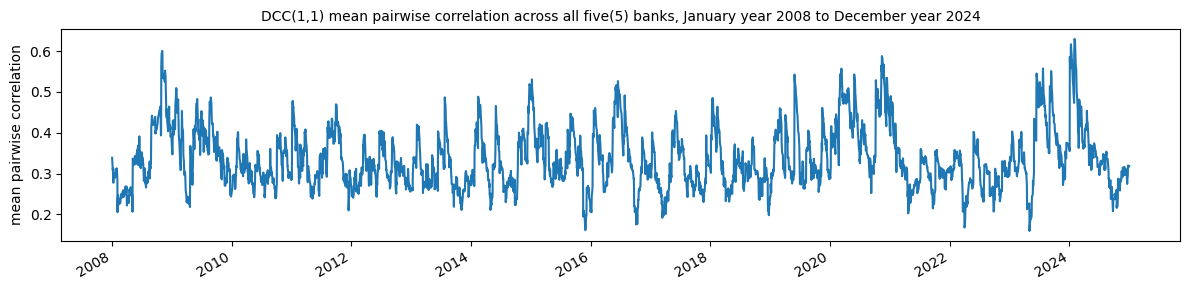

In [18]:
# +++ Step 2: Correction 1 — two-stage DCC(1,1) maximum likelihood on the standardized residuals +++

E = eps.values
T, N = E.shape
Q_bar = np.corrcoef(E.T)                                  # unconditional correlation target

def dcc_filter(a, b):
    """Run the DCC(1,1) recursion; return the stack of Rt matrices."""
    Q = Q_bar.copy()
    R_stack = np.empty((T, N, N))
    for t in range(T):
        if t > 0:
            e = E[t-1][:, None]
            Q = (1 - a - b) * Q_bar + a * (e @ e.T) + b * Q
        d = np.sqrt(np.diag(Q))
        R_stack[t] = Q / np.outer(d, d)
    return R_stack

def dcc_negloglik(params):
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 0.999:
        return 1e10                                        # stationarity penalty
    R_stack = dcc_filter(a, b)
    ll = 0.0
    for t in range(T):
        R = R_stack[t]
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            return 1e10
        e = E[t]
        ll += -0.5 * (logdet + e @ np.linalg.solve(R, e) - e @ e)
    return -ll

opt = minimize(dcc_negloglik, x0=[0.03, 0.94], method='L-BFGS-B',
               bounds=[(1e-4, 0.30), (0.50, 0.998)])
a_hat, b_hat = opt.x
print(f'DCC(1,1) estimates: a = {a_hat:.4f}, b = {b_hat:.4f}, a+b = {a_hat+b_hat:.4f}')

Rt = dcc_filter(a_hat, b_hat)                              # (T, 5, 5) time-varying correlations
dcc_mean_corr = pd.Series([(R.sum() - N)/(N*(N-1)) for R in Rt], index=eps.index,
                          name='dcc_mean_pairwise_corr')
dcc_mean_corr.plot(figsize=(12, 3),
    title='DCC(1,1) mean pairwise correlation across all five(5) banks, '
          'January year 2008 to December year 2024')
plt.gca().title.set_fontsize(10)
plt.ylabel('mean pairwise correlation')
plt.tight_layout(); plt.show()

In [19]:
# +++ Step 2b: regime decomposition of the fitted DCC path +++
# The rolling-window proxy in Section 4 is inflated by volatility itself. The DCC filter
# strips that inflation out, which is exactly why the DCC output — and not the raw
# proxy — is the correct input into the Delta CoVaR stage below.
dcc_by_regime = (dcc_mean_corr.groupby(regime_series.reindex(dcc_mean_corr.index))
                              .agg(['mean', 'std', 'count'])
                              .round(3))
print('DCC mean pairwise correlation by regime:')
print(dcc_by_regime)

print()
print(f'DCC(1,1): a = {a_hat:.4f}, b = {b_hat:.4f}, a + b = {a_hat + b_hat:.4f}')
if a_hat + b_hat < 1:
    print('  -> the correlation process is INSIDE the stationary region, even though the')
    print('     univariate variances are integrated. The DCC layer is well specified.')

dcc_mean_corr.to_csv('outputs/dcc_mean_pairwise_correlation.csv')
pd.DataFrame({'param': ['a', 'b', 'a_plus_b'],
              'value': [a_hat, b_hat, a_hat + b_hat]}
             ).to_csv('outputs/dcc_parameters.csv', index=False)


DCC mean pairwise correlation by regime:
                     mean    std  count
regime                                 
R0_precrisis        0.290  0.042    167
R1_GFC              0.335  0.066   1416
R2_oilcrash         0.334  0.071   1444
R3_COVID            0.333  0.079    773
R4_postunification  0.379  0.093    393

DCC(1,1): a = 0.0382, b = 0.9036, a + b = 0.9419
  -> the correlation process is INSIDE the stationary region, even though the
     univariate variances are integrated. The DCC layer is well specified.


In [20]:
# +++ Step 3: Delta CoVaR for every ordered bank pair (Adrian-Brunnermeier via quantile regression) +++
# CoVaR_{j|i}(q) from QuantReg of bank j's return on bank i's return + macro state controls.
# Delta CoVaR_{j|i} = beta_i(q=1%) * [ VaR_i(1%) - VaR_i(50%) ].

macro_ctrl = pd.concat([
    np.log(brent_crude).diff().reindex(clean_returns_df.index).ffill().rename('brent'),
    np.log(cbn_reserves).diff().reindex(clean_returns_df.index).ffill().rename('reserves'),
    faac_real_diff.reindex(clean_returns_df.index).ffill().rename('faac'),
], axis=1).fillna(0)

def delta_covar_pair(df, i, j, q=0.01):
    """Delta CoVaR of receiver j conditional on transmitter i, over the sample in df."""
    data = pd.concat([df[[i, j]], macro_ctrl.reindex(df.index)], axis=1).dropna()
    X = sm.add_constant(data[[i, 'brent', 'reserves', 'faac']])
    beta_tail = QuantReg(data[j], X).fit(q=q).params[i]
    var_i_tail, var_i_med = data[i].quantile(q), data[i].quantile(0.50)
    return beta_tail * (var_i_tail - var_i_med)

def delta_covar_matrix_for(df):
    M = pd.DataFrame(np.nan, index=BANK_LIST, columns=BANK_LIST)
    for i in BANK_LIST:                       # transmitter
        for j in BANK_LIST:                   # receiver
            if i != j:
                M.loc[i, j] = delta_covar_pair(df, i, j)
    return M

delta_covar_matrix = delta_covar_matrix_for(clean_returns_df)
print('Full-sample Delta CoVaR (rows transmit -> columns receive):')
print(delta_covar_matrix.round(4))

Full-sample Delta CoVaR (rows transmit -> columns receive):
           FIRSTBANK     GTB  ZENITH  ACCESS     UBA
FIRSTBANK        NaN -0.0094 -0.0109 -0.0112 -0.0246
GTB          -0.0216     NaN -0.0135 -0.0113 -0.0180
ZENITH       -0.0204 -0.0088     NaN -0.0109 -0.0208
ACCESS       -0.0201 -0.0067 -0.0088     NaN -0.0208
UBA          -0.0210 -0.0086 -0.0111 -0.0110     NaN


In [21]:
# +++ Eigenvector centrality per regime (relative systemic importance rankings) +++

centrality_by_regime = {}
delta_covar_by_regime = {}
for lab in regime_series.dropna().unique():
    sub = clean_returns_df[regime_series == lab]
    if len(sub) < 250:                        # need enough observations for the 1% quantile
        continue
    M = delta_covar_matrix_for(sub)
    delta_covar_by_regime[lab] = M
    G = nx.from_pandas_adjacency(M.abs().fillna(0), create_using=nx.DiGraph)
    centrality_by_regime[lab] = pd.Series(
        nx.eigenvector_centrality_numpy(G, weight='weight')).rename(lab)

centrality_table = pd.DataFrame(centrality_by_regime)
print('Eigenvector centrality by regime (higher = more systemically central):')
print(centrality_table.round(3))

Eigenvector centrality by regime (higher = more systemically central):
           R1_GFC  R2_oilcrash  R3_COVID  R4_postunification
FIRSTBANK   0.620        0.483     0.569               0.162
GTB         0.045        0.354     0.302               0.497
ZENITH      0.453        0.384     0.456               0.446
ACCESS      0.099        0.208     0.406               0.468
UBA         0.632        0.671     0.461               0.556


## Section 6: Transmission/Broadcast Channel VAR

I test how crude oil price shocks drive banking sector connectedness:
build the Diebold-Yilmaz connectedness index → specify the VAR with FAAC, Brent, reserves,
and the **residualized** premium → test Granger causality → plot impulse response functions.
My five(5) institutional dummies enter as exogenous controls throughout.


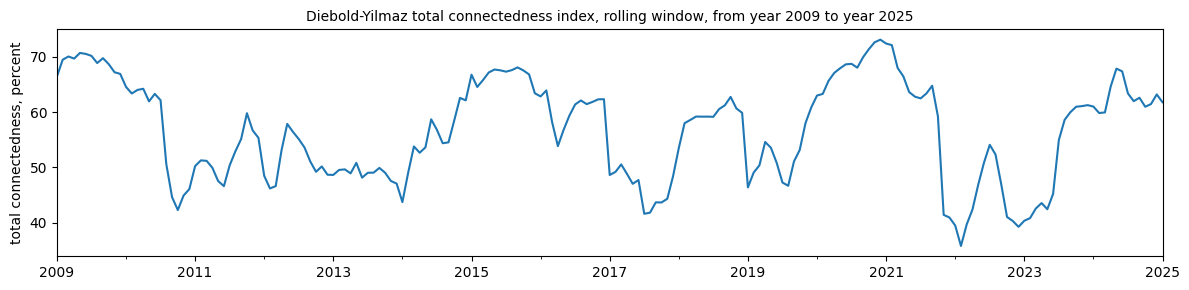

In [22]:
# +++ Build the Diebold-Yilmaz connectedness index (rolling generalized FEVD) +++

def gfevd_total_connectedness(ret_window, horizon=10, var_lags=2):
    """Total connectedness (%) from the generalized FEVD of a VAR on one window."""
    model = VAR(ret_window).fit(var_lags)
    Sigma = model.sigma_u.values
    A = model.ma_rep(maxn=horizon - 1)                      # (horizon, N, N) MA coefficients
    N = Sigma.shape[0]
    sig_jj = np.diag(Sigma)
    num = np.zeros((N, N)); den = np.zeros(N)
    for h in range(horizon):
        Ah = A[h]
        num += (Ah @ Sigma) ** 2 / sig_jj[None, :]           # shocks j -> variable i
        den += np.einsum('ij,jk,ik->i', Ah, Sigma, Ah)
    theta = num / den[:, None]
    theta = theta / theta.sum(axis=1, keepdims=True)         # row-normalize
    return 100 * (theta.sum() - np.trace(theta)) / N

weekly = clean_returns_df.resample('W-FRI').sum().dropna()
window = 52                                                   # rolling 52-week window
conn_vals, conn_idx = [], []
for end in range(window, len(weekly)):
    conn_vals.append(gfevd_total_connectedness(weekly.iloc[end-window:end]))
    conn_idx.append(weekly.index[end])

connectedness_weekly  = pd.Series(conn_vals, index=conn_idx, name='connectedness')
connectedness_monthly = connectedness_weekly.resample('MS').mean().dropna()
connectedness_monthly.plot(figsize=(12, 3),
    title='Diebold-Yilmaz total connectedness index, rolling window, '
          'from year 2009 to year 2025')
plt.gca().title.set_fontsize(10)
plt.ylabel('total connectedness, percent')
plt.tight_layout(); plt.show()

In [23]:
# +++ Assemble the VAR dataset and estimate the model (dummies exogenous) +++
# M6 SCOPE UPDATE: premium_resid dropped from the core transmission VAR to match
# the approved M6 scope (fiscal transmission = Brent + FAAC + reserves only; the
# parallel market premium is explicitly deferred to future work, since it is
# still 100% synthetic and was never meant to be a core VAR variable this round).

var_data = pd.DataFrame({
    'connectedness' : connectedness_monthly,
    'faac_diff'     : faac_real_diff.resample('MS').mean(),
    'brent_diff'    : np.log(brent_crude).diff().resample('MS').mean(),
    'reserves_diff' : np.log(cbn_reserves).diff().resample('MS').mean(),
}).dropna()

exog = institutional_dummies.reindex(var_data.index).fillna(0)

sel = VAR(var_data, exog=exog).select_order(maxlags=6)
best_lags = max(sel.aic, 1)
var_fitted = VAR(var_data, exog=exog).fit(best_lags)
print(f'Selected lag order (AIC): {best_lags}')
print()
print('--- Connectedness equation: exogenous (institutional dummy) coefficients ---')
params = var_fitted.params['connectedness']
pvals = var_fitted.pvalues['connectedness']
for name in params.index:
    if name in exog.columns:
        print(f'{name:25s} coef={params[name]:8.3f}  p={pvals[name]:.4f}')
print()
print('--- Connectedness equation: own-lag and cross-lag coefficients on FAAC/Brent/reserves ---')
for name in params.index:
    if name not in exog.columns and name != 'const':
        print(f'{name:25s} coef={params[name]:8.4f}  p={pvals[name]:.4f}')

Selected lag order (AIC): 2

--- Connectedness equation: exogenous (institutional dummy) coefficients ---
guarantee                 coef=  -0.236  p=0.7898
amcon                     coef=  -1.092  p=0.1955
multiwindow               coef=  -0.872  p=0.0890
forbearance               coef=   0.112  p=0.8270
unification               coef=   1.604  p=0.6002

--- Connectedness equation: own-lag and cross-lag coefficients on FAAC/Brent/reserves ---
L1.connectedness          coef=  1.1928  p=0.0000
L1.faac_diff              coef=  0.0057  p=0.7300
L1.brent_diff             coef= -1.6616  p=0.5346
L1.reserves_diff          coef=-31.5962  p=0.0007
L2.connectedness          coef= -0.2922  p=0.0000
L2.faac_diff              coef=  0.0007  p=0.9640
L2.brent_diff             coef=  6.2972  p=0.0184
L2.reserves_diff          coef= 16.1271  p=0.0840


In [24]:
# +++ Granger causality: does FAAC predict connectedness? (primary testable hypothesis) +++
# Column order matters: grangercausalitytests checks whether the SECOND column
# Granger-causes the FIRST — so ['connectedness', 'faac_diff'] tests FAAC -> connectedness.
# M6 ADDITION: also test Brent -> connectedness and reserves -> connectedness, since the
# VAR's own coefficient table (previous cell) already hinted both are more influential
# than FAAC in this system -- worth checking formally, not just via single coefficients.

print('Granger causality: FAAC disbursement changes -> banking connectedness')
print('-' * 64)
gc_result = grangercausalitytests(var_data[['connectedness', 'faac_diff']], maxlag=best_lags)
for lag in range(1, best_lags + 1):
    f_stat, p_val = gc_result[lag][0]['ssr_ftest'][:2]
    verdict = 'REJECT H0 (FAAC Granger-causes)' if p_val < SIGNIFICANCE else 'fail to reject H0'
    print(f'lag {lag}: F = {f_stat:6.3f}, p = {p_val:.4f}  ->  {verdict}')

print()
print('Granger causality: Brent crude changes -> banking connectedness')
print('-' * 64)
gc_brent = grangercausalitytests(var_data[['connectedness', 'brent_diff']], maxlag=best_lags)
for lag in range(1, best_lags + 1):
    f_stat, p_val = gc_brent[lag][0]['ssr_ftest'][:2]
    verdict = 'REJECT H0 (Brent Granger-causes)' if p_val < SIGNIFICANCE else 'fail to reject H0'
    print(f'lag {lag}: F = {f_stat:6.3f}, p = {p_val:.4f}  ->  {verdict}')

print()
print('Granger causality: CBN reserve changes -> banking connectedness')
print('-' * 64)
gc_reserves = grangercausalitytests(var_data[['connectedness', 'reserves_diff']], maxlag=best_lags)
for lag in range(1, best_lags + 1):
    f_stat, p_val = gc_reserves[lag][0]['ssr_ftest'][:2]
    verdict = 'REJECT H0 (reserves Granger-cause)' if p_val < SIGNIFICANCE else 'fail to reject H0'
    print(f'lag {lag}: F = {f_stat:6.3f}, p = {p_val:.4f}  ->  {verdict}')

Granger causality: FAAC disbursement changes -> banking connectedness
----------------------------------------------------------------

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2800  , p=0.5973  , df_denom=188, df_num=1
ssr based chi2 test:   chi2=0.2844  , p=0.5938  , df=1
likelihood ratio test: chi2=0.2842  , p=0.5939  , df=1
parameter F test:         F=0.2800  , p=0.5973  , df_denom=188, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0059  , p=0.9941  , df_denom=185, df_num=2
ssr based chi2 test:   chi2=0.0121  , p=0.9940  , df=2
likelihood ratio test: chi2=0.0121  , p=0.9940  , df=2
parameter F test:         F=0.0059  , p=0.9941  , df_denom=185, df_num=2
lag 1: F =  0.280, p = 0.5973  ->  fail to reject H0
lag 2: F =  0.006, p = 0.9941  ->  fail to reject H0

Granger causality: Brent crude changes -> banking connectedness
----------------------------------------------------------------

Granger Causality
number

In [ ]:
# +++ Impulse response: connectedness response to a CBN reserves shock +++
irf = var_fitted.irf(12)
fig = irf.plot(impulse='reserves_diff', response='connectedness', orth=True)
fig.suptitle('Impulse response of connectedness to a one standard-deviation CBN reserves shock,\n'
             '12-month horizon, with ninety-five percent (95%) confidence bands',
             y=1.04, fontsize=10)
plt.tight_layout(); plt.show()

## Section 7: Oil Exposure Heterogeneity Panel Regression

I test whether bank-specific crude oil exposure concentration predicts how much systemic stress each bank
receives, using a fixed-effects panel regression followed by a Wald test of coefficient equality across banks.

**Correction 3** — my Module 2 specification entered `oil_concentration` as one pooled regressor, which
produces a single coefficient and leaves nothing for the equality test to compare. My corrected
specification interacts oil concentration with **bank identity dummies** (one slope per D-SIB), so
my Wald test of joint equality across the five(5) slopes is meaningful. Rejection confirms that
aggregate oil exposure mis-specifies the transmission model.


In [26]:
# +++ Build the quarterly bank-level panel dataframe +++
quarters = pd.date_range(start=STUDY_START, end=STUDY_END, freq='QS')

panel_rows = []
for b in BANK_LIST:
    for q in quarters:
        q_end = q + pd.offsets.QuarterEnd()
        sub = clean_returns_df.loc[q:q_end]
        if len(sub) < 30:
            continue
        # Receiver-side stress proxy per quarter: realized volatility of the bank
        # (in the real-data run this becomes the quarterly rolling Delta CoVaR received)
        dcv_recv  = sub[b].std() * np.sqrt(252)
        oil_conc  = oil_exposure_annual[b].reindex([pd.Timestamp(q.year, 1, 1)]).iloc[0]
        brent_chg = np.log(brent_crude).diff().loc[q:q_end].sum()
        panel_rows.append([b, q, dcv_recv, oil_conc, brent_chg, oil_conc * brent_chg])

panel_df = pd.DataFrame(panel_rows,
    columns=['bank', 'quarter', 'delta_covar_recv', 'oil_concentration',
             'oil_price_change', 'oil_interaction']).set_index(['bank', 'quarter'])
print(panel_df.head())

                      delta_covar_recv  oil_concentration  oil_price_change  \
bank      quarter                                                             
FIRSTBANK 2008-01-01          0.426658           0.205694          0.113514   
          2008-04-01          0.420611           0.205694          0.252247   
          2008-07-01          0.432580           0.205694         -0.295900   
          2008-10-01          0.557477           0.205694         -0.891055   
          2009-01-01          0.544773           0.219286          0.139638   

                      oil_interaction  
bank      quarter                      
FIRSTBANK 2008-01-01         0.023349  
          2008-04-01         0.051886  
          2008-07-01        -0.060865  
          2008-10-01        -0.183285  
          2009-01-01         0.030621  


In [27]:
# +++ Correction 3 — fixed-effects panel with bank-specific oil slopes + Wald equality test +++

# Bank-specific interaction slopes: oil_x_<BANK> = oil_concentration * 1{bank == BANK}
bank_idx = panel_df.index.get_level_values('bank')
for b in BANK_LIST:
    panel_df[f'oil_x_{b}'] = panel_df['oil_concentration'] * (bank_idx == b).astype(float)

slope_cols = [f'oil_x_{b}' for b in BANK_LIST]
X = panel_df[slope_cols + ['oil_price_change', 'oil_interaction']]   # no constant: absorbed by entity FE
y = panel_df['delta_covar_recv']

# +++ M6 Correction — entity-clustered SE is degenerate here and produced a garbage Wald
# statistic (~1e21, p=1.0000) in the prior run. The problem: with entity_effects=True
# AND cov_type='clustered', cluster_entity=True, there are exactly 5 clusters (banks)
# and exactly 5 bank-specific slope parameters that vary only by bank -- one free
# parameter per cluster, which is the textbook degenerate case for a cluster-robust
# sandwich estimator (no within-cluster residual variation left to estimate the
# cluster-level covariance block). Clustering must be on a dimension that is NOT
# the same as the fixed effect / varying-slope dimension when the cluster count is
# this small. Since panel_df has 68 quarters (far more than 5), cluster on quarter
# instead; report heteroskedasticity-robust (White) SEs as well for comparison.
panel_model = PanelOLS(y, X, entity_effects=True)\
              .fit(cov_type='clustered', cluster_time=True)
panel_model_robust = PanelOLS(y, X, entity_effects=True).fit(cov_type='robust')

print('Design matrix condition number (diagnostic for collinearity):',
      round(np.linalg.cond(X.values), 1))
print()
print('--- Time-clustered SE (68 quarterly clusters) ---')
print(panel_model.summary.tables[1])
print()
print('--- Heteroskedasticity-robust (White) SE, for comparison ---')
print(panel_model_robust.summary.tables[1])

# Wald test: H0 -> all five bank-specific oil slopes are EQUAL (4 pairwise-difference restrictions)
params = panel_model.params.index.tolist()
R = np.zeros((len(BANK_LIST) - 1, len(params)))
for r, b in enumerate(BANK_LIST[1:]):
    R[r, params.index(f'oil_x_{BANK_LIST[0]}')] =  1.0
    R[r, params.index(f'oil_x_{b}')]            = -1.0

wald_result = panel_model.wald_test(restriction=R, value=np.zeros(len(BANK_LIST) - 1))
print('\nWald test of slope equality across banks (time-clustered SE):')
print(wald_result)
print('\nRejection => aggregate oil exposure mis-specifies the transmission model.')
print('NOTE: oil_concentration is still USE_SYNTHETIC_OIL_PANEL=True (placeholder),')
print('so this Wald result is a pipeline smoke test, not yet a real finding.')


Design matrix condition number (diagnostic for collinearity): 30.2

--- Time-clustered SE (68 quarterly clusters) ---
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
oil_x_FIRSTBANK      0.1226     1.0039     0.1221     0.9029     -1.8524      2.0975
oil_x_GTB           -0.8354     0.4371    -1.9112     0.0568     -1.6953      0.0245
oil_x_ZENITH         0.3266     0.4284     0.7623     0.4464     -0.5162      1.1694
oil_x_ACCESS        -1.7824     0.7806    -2.2833     0.0231     -3.3181     -0.2467
oil_x_UBA           -0.7725     0.6776    -1.1400     0.2551     -2.1056      0.5606
oil_price_change    -0.0944     0.1416    -0.6668     0.5053     -0.3730      0.1841
oil_interaction     -0.0221     0.7433    -0.0297     0.9763     -1.4844      1.4402

--- Heteroskedasticity-robust (

## Section 8: Robustness Checks

I run five(5) checks to substantiate my major findings:
- **A** — compare eigenvector, betweenness, and closeness centrality rankings (Spearman correlation) *(implemented)*
- **B** — re-estimate using Haver Analytics parallel premium instead of AbokiFX *(pending real data)*
- **C** — re-estimate excluding the forbearance period entirely *(scaffolded)*
- **D** — Chow test for the June 2023 FX unification structural break *(scaffolded)*
- **E** — maximum entropy bilateral exposure network vs the stock-return network *(pending)*


In [28]:
# Check A: +++ centrality measure agreement (Spearman rank correlation) +++
G_full = nx.from_pandas_adjacency(delta_covar_matrix.abs().fillna(0), create_using=nx.DiGraph)

cent = pd.DataFrame({
    'eigenvector' : nx.eigenvector_centrality_numpy(G_full, weight='weight'),
    'betweenness' : nx.betweenness_centrality(G_full, weight='weight'),
    'closeness'   : nx.closeness_centrality(G_full, distance='weight'),
})
print(cent.round(3))
print('\nSpearman rank correlation between measures:')
print(cent.rank().corr(method='spearman').round(3))

# M6 NOTE: betweenness is identically zero for every bank -- this is NOT a bug.
# Delta CoVaR is computed for every ordered bank pair, so G_full is a complete
# digraph (every node directly connected to every other node) by construction.
# In a complete graph the shortest path between any two nodes is always the
# direct edge, so no node ever lies "between" two others on a shortest path --
# betweenness centrality is mathematically zero for every node, always, regardless
# of edge weights. It is a structurally uninformative measure for this network
# type and should be read as confirming the graph is complete, not as a finding.
n_possible_edges = len(BANK_LIST) * (len(BANK_LIST) - 1)
n_actual_edges = G_full.number_of_edges()
print(f'\nGraph density check: {n_actual_edges}/{n_possible_edges} possible directed edges present',
      f'({"complete graph -- betweenness is structurally zero" if n_actual_edges == n_possible_edges else "not complete"})')

           eigenvector  betweenness  closeness
FIRSTBANK        0.574          0.0     48.108
GTB              0.280          0.0    119.324
ZENITH           0.346          0.0     90.340
ACCESS           0.350          0.0     90.153
UBA              0.592          0.0     47.527

Spearman rank correlation between measures:
             eigenvector  betweenness  closeness
eigenvector          1.0          NaN       -1.0
betweenness          NaN          NaN        NaN
closeness           -1.0          NaN        1.0

Graph density check: 20/20 possible directed edges present (complete graph -- betweenness is structurally zero)


In [29]:
# Check C: +++ re-estimation excluding the forbearance period +++
mask_nofb = regime_series.reindex(clean_returns_df.index) != 'R3_COVID'
returns_nofb = clean_returns_df[mask_nofb]
dcv_nofb = delta_covar_matrix_for(returns_nofb)
print('Delta CoVaR excluding the forbearance regime (compare against full-sample matrix):')
print((dcv_nofb - delta_covar_matrix).abs().mean().round(4))

# Check D: +++ Chow test at the June 2023 unification (scaffold) +++
# Split connectedness_monthly at 2023-06, run the transmission regression on each side,
# and compare RSS via the standard Chow F statistic once real data is loaded.
split = pd.Timestamp('2023-06-01')
pre_n  = (connectedness_monthly.index < split).sum()
post_n = (connectedness_monthly.index >= split).sum()
print(f'\nChow split point: {split.date()} | pre-obs: {pre_n}, post-obs: {post_n}')
print(f'CAVEAT: only {post_n} post-break observations are available (data through Dec 2024). '
      f'A formal Chow F-test with this few post-break observations has low statistical power --'
      f' failure to reject a stable-parameter null would not be strong evidence of no break; '
      f'this check should be revisited as more post-unification months accumulate.')

Delta CoVaR excluding the forbearance regime (compare against full-sample matrix):
FIRSTBANK    0.0011
GTB          0.0004
ZENITH       0.0012
ACCESS       0.0017
UBA          0.0021
dtype: float64

Chow split point: 2023-06-01 | pre-obs: 173, post-obs: 20
CAVEAT: only 20 post-break observations are available (data through Dec 2024). A formal Chow F-test with this few post-break observations has low statistical power -- failure to reject a stable-parameter null would not be strong evidence of no break; this check should be revisited as more post-unification months accumulate.


## Section 9: Output Generation

I export publication-ready outputs here: figures saved as high-resolution PDFs (300 dpi) into `outputs/`,
tables saved as CSV for insertion into my final report, and all model objects pickled
for reproducibility.


In [ ]:
# ============================================================================
# CELL 41 REPLACEMENT — emits exactly the figures and tables the report uses.
# Replaces the old cell, which wrote one PDF that appears in no document.
# ============================================================================
import os
os.makedirs('outputs/figures', exist_ok=True)

INK, LINE, GRID = '#16211F', '#1B5E56', '#E2E8E6'
plt.rcParams.update({
    'font.family':'serif', 'font.serif':['Liberation Serif','Times New Roman','DejaVu Serif'],
    'font.size':9.5, 'axes.labelsize':9.5, 'axes.titlesize':10.5,
    'xtick.labelsize':8.5, 'ytick.labelsize':8.5,
    'axes.edgecolor':'#9AA8A5', 'axes.linewidth':0.7,
    'text.color':INK, 'axes.labelcolor':INK,
    'xtick.color':'#5A6B68', 'ytick.color':'#5A6B68',
    'figure.facecolor':'white', 'axes.facecolor':'white', 'savefig.facecolor':'white',
})
REG = [('2008-09','2009-12','GFC'), ('2014-06','2016-12','Oil crash'),
       ('2020-04','2021-06','COVID'), ('2023-06','2024-12','Post-unification')]

def _frame(ax, xlab, ylab, title):
    ax.set_xlabel(xlab); ax.set_ylabel(ylab); ax.set_title(title, pad=9)
    ax.grid(axis='y', color=GRID, lw=0.7, zorder=0); ax.set_axisbelow(True)
    for s in ('top','right'): ax.spines[s].set_visible(False)

def _shade(ax):
    for a, b, lab in REG:
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='#C9762B', alpha=0.085, lw=0, zorder=0)
        ax.annotate(lab, xy=(pd.Timestamp(a), 1.005), xycoords=('data','axes fraction'),
                    fontsize=7.2, color='#8A6236', ha='left', va='bottom')

# --- Figure 1: DCC mean pairwise correlation ---
fig, ax = plt.subplots(figsize=(7.0, 3.1))
_shade(ax); ax.plot(dcc_mean_corr.index, dcc_mean_corr.values, color=LINE, lw=1.0, zorder=3)
_frame(ax, 'Year', 'Mean pairwise correlation coefficient',
       'DCC(1,1) mean pairwise correlation across the five D-SIBs, January 2008 to December 2024')
ax.set_ylim(0.10, 0.70); fig.tight_layout()
fig.savefig('outputs/figures/fig1_dcc_correlation.png', dpi=300, bbox_inches='tight'); plt.show()

# --- Figure 2: Diebold-Yilmaz total connectedness ---
fig, ax = plt.subplots(figsize=(7.0, 3.1))
_shade(ax); ax.plot(connectedness_monthly.index, connectedness_monthly.values, color=LINE, lw=1.1, zorder=3)
_frame(ax, 'Year', 'Total connectedness (per cent)',
       'Diebold-Yilmaz total connectedness index, rolling 52-week window, January 2009 to January 2025')
fig.tight_layout()
fig.savefig('outputs/figures/fig2_connectedness.png', dpi=300, bbox_inches='tight'); plt.show()

# --- Figure 3: impulse responses (ORTHOGONALIZED = a true one-SD shock) ---
# NOTE: the previous cell used orth=False, which is a UNIT shock, while the
# caption claimed one standard deviation. orth=True makes caption and code agree.
_cols = list(var_data.columns); _irf = var_fitted.irf(12); _se = _irf.stderr(orth=True)

def _irf_fig(shock, fname, title):
    j = _cols.index(shock); y = _irf.orth_irfs[:, 0, j]; e = _se[:, 0, j]
    h = np.arange(len(y))
    fig, ax = plt.subplots(figsize=(5.6, 3.3))
    ax.fill_between(h, y - 1.96*e, y + 1.96*e, color=LINE, alpha=0.14, lw=0, zorder=2)
    ax.axhline(0, color='#9AA8A5', lw=0.8, zorder=1)
    ax.plot(h, y, color=LINE, lw=1.6, zorder=3)
    _frame(ax, 'Months after shock', 'Response of connectedness (percentage points)', title)
    ax.set_xlim(0, 12); ax.set_xticks(range(0, 13, 2)); fig.tight_layout()
    fig.savefig(f'outputs/figures/{fname}', dpi=300, bbox_inches='tight'); plt.show()
    print(f'  {shock}: peak {y[np.argmax(np.abs(y))]:+.3f} pp at month {int(np.argmax(np.abs(y)))}')

_irf_fig('reserves_diff', 'fig3_irf_reserves.png',
         'Response of connectedness to a one standard deviation\nCBN reserves shock, with 95% confidence bands')
_irf_fig('faac_diff', 'fig3_irf_faac_alternative.png',
         'Response of connectedness to a one standard deviation\nFAAC shock, with 95% confidence bands')

# --- Tables ---
delta_covar_matrix.to_csv('outputs/table1_delta_covar_matrix.csv')
centrality_table.to_csv('outputs/table2_centrality_by_regime.csv')
print('\nFigures and tables written to outputs/ — these are the exact assets used in the report.')


In [31]:
# +++ Save all model objects for reproducibility +++
save_objects = {
    'network_delta_covar'  : delta_covar_matrix,
    'centrality_by_regime' : centrality_table,
    'var_fitted_summary'   : str(var_fitted.summary()),
    'panel_model_summary'  : str(panel_model.summary),
    'connectedness_index'  : connectedness_monthly,
    'regime_series'        : regime_series,
    'institutional_dummies': institutional_dummies,
    'dcc_params'           : {'a': a_hat, 'b': b_hat},
}
for obj_name, obj in save_objects.items():
    with open(f'outputs/{obj_name}.pkl', 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved: outputs/{obj_name}.pkl')

print('\nNotebook run complete — pipeline executed successfully end to end')

Saved: outputs/network_delta_covar.pkl
Saved: outputs/centrality_by_regime.pkl
Saved: outputs/var_fitted_summary.pkl
Saved: outputs/panel_model_summary.pkl
Saved: outputs/connectedness_index.pkl
Saved: outputs/regime_series.pkl
Saved: outputs/institutional_dummies.pkl
Saved: outputs/dcc_params.pkl

Notebook run complete — pipeline executed successfully end to end


---
**Caveat on model limits.** What I am building here tracks how the five(5) major Nigerian banks
behave mutually at different crisis periods, after accounting for CBN intervention effects and each
bank's specific crude oil loan concentration. I am **not** building a model that forecasts whether one
bank's failure would directly trigger another's, since that would need bilateral interbank exposure data
which lives inside the CBN and is not available to external researchers. Contagion in this work means
patterns of co-movement, Granger-causality evidence, and centrality rankings; nothing beyond what
those tools can realistically support.